# GoldCoin HIPAA — Full Evaluation Summary

Generate summary tables and plots from `full_eval` pipeline runs (applicability + compliance).

**Tasks:**
- **Applicability**: Binary classification — is HIPAA applicable to this case? (Applicable / Not Applicable)
- **Compliance**: Classification — does this case permit or forbid the action under HIPAA? (Permit / Forbid)

**Reference baselines** (from [Xiang et al., 2024](https://arxiv.org/abs/2406.11149)):

| Model | Applicability | Compliance |
|-------|--------------|------------|
| Llama2-13B | 99.53 | 64.83 |
| Mistral-7B | 97.66 | 66.98 |

In [1]:
import json
import os
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from IPython.display import display, HTML

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Configuration

Point `RUN_DIRS` at one or more `full_eval` pipeline output directories. Each should contain
`outputs/compute_metrics_applicability/metrics.json` and `outputs/compute_metrics_compliance/metrics.json`.

In [2]:
# ── Edit these ──────────────────────────────────────────────────────────────
# Each entry is a path to a full_eval pipeline output root (the dir containing outputs/).
RUN_DIRS = [
    "/share/pierson/matt/UAIR/multirun/2026-03-09/22-40-46/0/goldcoin_hipaa",
    # Add more runs here, e.g.:
    # "/share/pierson/matt/UAIR/multirun/2026-03-10/10-00-00/0/goldcoin_hipaa",
]

# Optional: override model display names (same order as RUN_DIRS).
# Set to None to auto-detect from .hydra/config.yaml.
MODEL_NAMES = None  # e.g. ["Qwen2.5-7B-Instruct", "Llama-3.3-70B-Instruct"]

# Reference baselines from Xiang et al. (2024) Table 2 — full-feature results only.
# Each entry: (model_name, applicability_acc, compliance_acc)
REFERENCE_BASELINES = [
    ("Llama2-13B",  99.53, 64.83),
    ("Mistral-7B",  97.66, 66.98),
]

## 2. Load Metrics

In [3]:
def find_task_metrics(run_dir: str, task: str) -> Optional[str]:
    """Locate metrics.json for a given task (applicability or compliance)."""
    candidates = [
        os.path.join(run_dir, "outputs", f"compute_metrics_{task}", "metrics.json"),
        os.path.join(run_dir, f"compute_metrics_{task}", "metrics.json"),
    ]
    for c in candidates:
        if os.path.isfile(c):
            return c
    return None


def find_hydra_config(run_dir: str) -> Optional[str]:
    """Try to find the Hydra config.yaml saved alongside this run."""
    p = Path(run_dir)
    for ancestor in [p, p.parent, p.parent.parent]:
        hydra_cfg = ancestor / ".hydra" / "config.yaml"
        if hydra_cfg.is_file():
            return str(hydra_cfg)
    return None


def extract_model_name(run_dir: str) -> str:
    """Auto-detect model name from Hydra config or directory name."""
    hydra_cfg_path = find_hydra_config(run_dir)
    if hydra_cfg_path:
        try:
            import yaml
            with open(hydra_cfg_path) as f:
                cfg = yaml.safe_load(f)
            model_source = cfg.get("model", {}).get("model_source", "")
            if model_source:
                return Path(model_source).name
        except Exception:
            pass
    return Path(run_dir).parent.name


def load_run(run_dir: str, model_name: Optional[str] = None) -> Optional[Dict[str, Any]]:
    """Load a single run's applicability + compliance metrics."""
    app_path = find_task_metrics(run_dir, "applicability")
    comp_path = find_task_metrics(run_dir, "compliance")

    if not app_path and not comp_path:
        print(f"WARNING: No metrics found in {run_dir}")
        return None

    app_metrics = json.load(open(app_path)) if app_path else None
    comp_metrics = json.load(open(comp_path)) if comp_path else None

    name = model_name or extract_model_name(run_dir)
    return {
        "model": name,
        "run_dir": run_dir,
        "applicability": app_metrics,
        "compliance": comp_metrics,
    }


# ── Load all runs ──
runs = []
for i, rd in enumerate(RUN_DIRS):
    name = MODEL_NAMES[i] if MODEL_NAMES and i < len(MODEL_NAMES) else None
    run = load_run(rd, model_name=name)
    if run:
        runs.append(run)

print(f"Loaded {len(runs)} run(s):")
for r in runs:
    app_n = r["applicability"]["total"] if r["applicability"] else "?"
    comp_n = r["compliance"]["total"] if r["compliance"] else "?"
    print(f"  {r['model']} — applicability: {app_n} samples, compliance: {comp_n} samples")

Loaded 1 run(s):
  Qwen2.5-7B-Instruct — applicability: 214 samples, compliance: 107 samples


## 3. Summary Table (Paper-Style)

Reproduces the structure from Xiang et al. (2024) Table 2: applicability accuracy, compliance accuracy,
and deltas vs. a reference model. Reference baselines are shown for context.

In [4]:
def build_summary_table(runs, baselines):
    """Build a combined summary DataFrame with reference baselines and our runs."""
    rows = []

    # Reference baselines
    for model, app_acc, comp_acc in baselines:
        rows.append({
            "Model": model,
            "Source": "reference",
            "App Acc (%)": app_acc,
            "App F1": np.nan,
            "Comp Acc (%)": comp_acc,
            "Comp F1": np.nan,
            "App Unparseable (%)": np.nan,
            "Comp Unparseable (%)": np.nan,
        })

    # Our runs
    for r in runs:
        app = r["applicability"] or {}
        comp = r["compliance"] or {}
        rows.append({
            "Model": r["model"],
            "Source": "ours",
            "App Acc (%)": round(app.get("accuracy", 0) * 100, 2),
            "App F1": round(app.get("macro_f1", 0), 4),
            "Comp Acc (%)": round(comp.get("accuracy", 0) * 100, 2),
            "Comp F1": round(comp.get("macro_f1", 0), 4),
            "App Unparseable (%)": round(app.get("unparseable_rate", 0) * 100, 1),
            "Comp Unparseable (%)": round(comp.get("unparseable_rate", 0) * 100, 1),
        })

    return pd.DataFrame(rows)


df_summary = build_summary_table(runs, REFERENCE_BASELINES)
df_summary

,Model,Source,App Acc (%),App F1,Comp Acc (%),Comp F1,App Unparseable (%),Comp Unparseable (%)
0,Llama2-13B,reference,99.530,NaN,64.830,NaN,NaN,NaN
1,Mistral-7B,reference,97.660,NaN,66.980,NaN,NaN,NaN
2,Qwen2.5-7B-Instruct,ours,97.200,0.972,77.570,0.631,0.000,0.000


## 4. Heatmap-Styled Comparison Table

Column-wise heatmap coloring (darker blue = better), grouped by reference vs. our models.

In [5]:
def heatmap_table(df: pd.DataFrame, heat_cols: List[str],
                   higher_better: Optional[Dict[str, bool]] = None,
                   group_col: str = "Source",
                   fmt: Optional[Dict[str, str]] = None) -> str:
    """Render an HTML table with per-column blue heatmap shading."""
    if higher_better is None:
        higher_better = {c: True for c in heat_cols}
    if fmt is None:
        fmt = {}

    cmap = plt.cm.Blues

    # Compute per-column min/max across all rows
    col_min = {c: df[c].dropna().min() for c in heat_cols}
    col_max = {c: df[c].dropna().max() for c in heat_cols}

    def cell_style(val, col):
        if pd.isna(val):
            return "background-color: #f5f5f5; color: #999;"
        vmin, vmax = col_min[col], col_max[col]
        if vmax == vmin:
            norm = 0.5
        else:
            norm = (val - vmin) / (vmax - vmin)
        if not higher_better.get(col, True):
            norm = 1.0 - norm
        rgba = cmap(0.15 + norm * 0.70)
        bg = mcolors.rgb2hex(rgba[:3])
        text_color = "#000" if norm < 0.6 else "#fff"
        return f"background-color: {bg}; color: {text_color};"

    html = ['<table style="border-collapse: collapse; font-family: sans-serif; font-size: 13px;">']
    show_cols = ["Model"] + heat_cols
    html.append("<thead><tr>")
    for c in show_cols:
        html.append(f'<th style="padding: 6px 10px; border-bottom: 2px solid #333; '
                     f'text-align: center; background: #f0f0f0;">{c}</th>')
    html.append("</tr></thead><tbody>")

    groups = df[group_col].unique()
    group_labels = {"reference": "Reference (Xiang et al., 2024)", "ours": "Our Models"}
    for g in groups:
        group_df = df[df[group_col] == g]
        label = group_labels.get(g, g.title())
        html.append(f'<tr><td colspan="{len(show_cols)}" style="padding: 4px 10px; '
                     f'font-weight: bold; background: #e8e8e8; border-top: 1px solid #ccc;">'
                     f'{label}</td></tr>')
        for _, row in group_df.iterrows():
            html.append("<tr>")
            for c in show_cols:
                val = row[c]
                if c == "Model":
                    html.append(f'<td style="padding: 4px 10px; font-weight: bold; '
                                 f'border-right: 1px solid #ddd;">{val}</td>')
                elif c in heat_cols:
                    style = cell_style(val, c)
                    f_str = fmt.get(c, ".2f" if "%" in c or "Acc" in c else ".4f")
                    txt = f"{val:{f_str}}" if not pd.isna(val) else "—"
                    html.append(f'<td style="padding: 4px 10px; text-align: center; {style}">{txt}</td>')
                else:
                    html.append(f'<td style="padding: 4px 10px; text-align: center;">{val}</td>')
            html.append("</tr>")

    html.append("</tbody></table>")
    return "\n".join(html)


heat_cols = ["App Acc (%)", "App F1", "Comp Acc (%)", "Comp F1"]
higher_better = {c: True for c in heat_cols}

html = heatmap_table(df_summary, heat_cols, higher_better)
display(HTML(html))

## 5. Accuracy Bar Chart — Our Models vs. Reference

Side-by-side comparison of applicability and compliance accuracy.

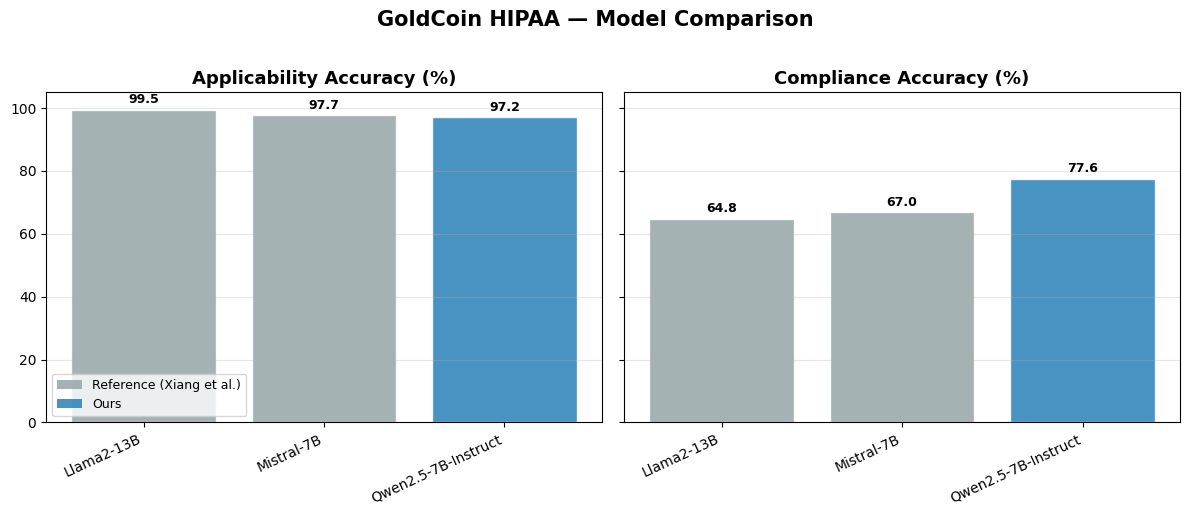

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

models = df_summary["Model"].tolist()
x = np.arange(len(models))
colors_ref = "#95a5a6"
colors_ours = "#2980b9"
bar_colors = [colors_ref if s == "reference" else colors_ours for s in df_summary["Source"]]

# Applicability
ax = axes[0]
vals = df_summary["App Acc (%)"].values
bars = ax.bar(x, vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_title("Applicability Accuracy (%)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Compliance
ax = axes[1]
vals = df_summary["Comp Acc (%)"].values
bars = ax.bar(x, vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_title("Compliance Accuracy (%)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Legend
from matplotlib.patches import Patch
axes[0].legend(
    [Patch(facecolor=colors_ref, alpha=0.85), Patch(facecolor=colors_ours, alpha=0.85)],
    ["Reference (Xiang et al.)", "Ours"],
    loc="lower left", fontsize=9,
)

plt.suptitle("GoldCoin HIPAA — Model Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Per-Class Breakdown

Precision, recall, and F1 for each class within both tasks.

In [7]:
def per_class_table(runs):
    """Build a per-class metrics table across all models and both tasks."""
    rows = []
    for r in runs:
        for task_key, task_label in [("applicability", "Applicability"), ("compliance", "Compliance")]:
            metrics = r.get(task_key)
            if not metrics:
                continue
            for label, pc in metrics.get("per_class", {}).items():
                counts = metrics.get("class_counts", {}).get(label, {})
                rows.append({
                    "Model": r["model"],
                    "Task": task_label,
                    "Class": label,
                    "Precision": pc.get("precision", np.nan),
                    "Recall": pc.get("recall", np.nan),
                    "F1": pc.get("f1", np.nan),
                    "Support": pc.get("support", counts.get("total", 0)),
                    "Correct": counts.get("correct", 0),
                    "Errors": counts.get("error", 0),
                })
    return pd.DataFrame(rows)


df_perclass = per_class_table(runs)
display(df_perclass.style.format({
    "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}",
    "Support": "{:.0f}", "Correct": "{:.0f}", "Errors": "{:.0f}",
}).set_caption("Per-Class Metrics"))

,Model,Task,Class,Precision,Recall,F1,Support,Correct,Errors
0,Qwen2.5-7B-Instruct,Applicability,Applicable,1.0000,0.9439,0.9712,107,101,6
1,Qwen2.5-7B-Instruct,Applicability,Not Applicable,0.9469,1.0000,0.9727,107,107,0
2,Qwen2.5-7B-Instruct,Compliance,Permit,0.8621,0.8621,0.8621,87,75,12
3,Qwen2.5-7B-Instruct,Compliance,Forbid,0.4000,0.4000,0.4000,20,8,12


## 7. Confusion Matrices

Side-by-side confusion matrices for applicability and compliance tasks.

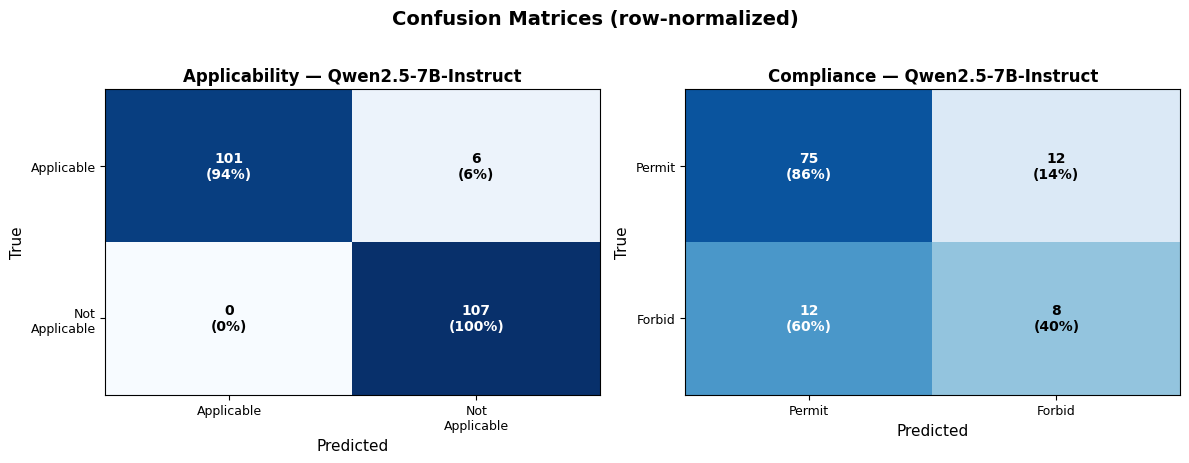

In [8]:
def plot_confusion_matrices(run):
    """Plot side-by-side confusion matrices for applicability and compliance."""
    tasks = [
        ("applicability", "Applicability"),
        ("compliance", "Compliance"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for idx, (task_key, task_label) in enumerate(tasks):
        ax = axes[idx]
        metrics = run.get(task_key)
        if not metrics or "confusion_matrix" not in metrics:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{task_label} — {run['model']}")
            continue

        cm_dict = metrics["confusion_matrix"]
        labels = list(cm_dict.keys())
        cm = np.array([[cm_dict[tl].get(pl, 0) for pl in labels] for tl in labels])

        # Row-normalize for display
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        # Wrap long labels
        short_labels = [l.replace(" ", "\n") if len(l) > 10 else l for l in labels]
        ax.set_xticklabels(short_labels, fontsize=9)
        ax.set_yticklabels(short_labels, fontsize=9)
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True", fontsize=11)
        ax.set_title(f"{task_label} — {run['model']}", fontsize=12, fontweight="bold")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                count = cm[i, j]
                pct = cm_norm[i, j] * 100
                color = "white" if cm_norm[i, j] > 0.5 else "black"
                ax.text(j, i, f"{count}\n({pct:.0f}%)", ha="center", va="center",
                        fontsize=10, color=color, fontweight="bold")

    plt.suptitle("Confusion Matrices (row-normalized)", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


for r in runs:
    plot_confusion_matrices(r)

## 8. Per-Class F1 Grouped Bar Chart

Visualize per-class F1 scores across models for both tasks.

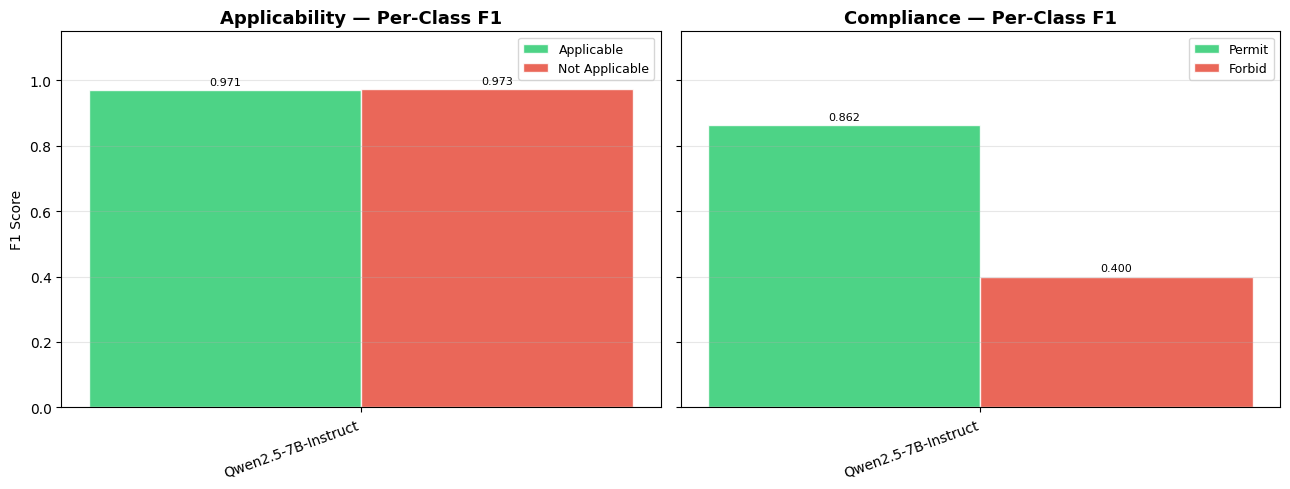

In [9]:
if not df_perclass.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    for idx, (task, ax) in enumerate(zip(["Applicability", "Compliance"], axes)):
        task_df = df_perclass[df_perclass["Task"] == task]
        if task_df.empty:
            continue

        models_in_task = task_df["Model"].unique()
        classes = task_df["Class"].unique()
        x = np.arange(len(models_in_task))
        n_classes = len(classes)
        width = 0.8 / max(n_classes, 1)

        colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]
        for i, cls in enumerate(classes):
            offset = (i - n_classes / 2 + 0.5) * width
            cls_df = task_df[task_df["Class"] == cls]
            vals = [cls_df[cls_df["Model"] == m]["F1"].values[0]
                    if len(cls_df[cls_df["Model"] == m]) > 0 else 0
                    for m in models_in_task]
            bars = ax.bar(x + offset, vals, width, label=cls,
                          color=colors[i % len(colors)], alpha=0.85, edgecolor="white")
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f"{val:.3f}", ha="center", va="bottom", fontsize=8)

        ax.set_title(f"{task} — Per-Class F1", fontsize=13, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(models_in_task, rotation=20, ha="right", fontsize=10)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("F1 Score" if idx == 0 else "")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## 9. Error Analysis — Compliance Misclassifications

Load the parsed responses and inspect which cases were misclassified.

In [10]:
for r in runs:
    parsed_path = os.path.join(r["run_dir"], "outputs", "parse_responses_compliance", "dataset.parquet")
    if not os.path.isfile(parsed_path):
        print(f"  {r['model']}: No parsed responses found at {parsed_path}")
        continue

    df_parsed = pd.read_parquet(parsed_path)
    print(f"── {r['model']} — Compliance Errors ──")

    if "prediction" in df_parsed.columns and "ground_truth" in df_parsed.columns:
        errors = df_parsed[df_parsed["prediction"] != df_parsed["ground_truth"]].copy()
        print(f"  Total errors: {len(errors)} / {len(df_parsed)}")
        print(f"  Error breakdown:")
        if len(errors) > 0:
            ct = errors.groupby(["ground_truth", "prediction"]).size().reset_index(name="count")
            display(ct)

            # Show a few example errors
            show_cols = [c for c in ["case_id", "ground_truth", "prediction", "generated_text"]
                         if c in errors.columns]
            print(f"\n  Sample misclassifications (first 5):")
            display(errors[show_cols].head(5))
    else:
        print(f"  Columns available: {list(df_parsed.columns)}")

── Qwen2.5-7B-Instruct — Compliance Errors ──
  Total errors: 24 / 107
  Error breakdown:


,ground_truth,prediction,count
0,Forbid,Permit,12
1,Permit,Forbid,12



  Sample misclassifications (first 5):


,case_id,ground_truth,prediction,generated_text
5,5,Permit,Forbid,The HIPAA Privacy Rule generally forbids the r...
11,11,Forbid,Permit,### Response:\n\nThe HIPAA Privacy Rule does n...
12,12,Forbid,Permit,### Response:\n\nBased on the HIPAA Privacy Ru...
17,17,Forbid,Permit,### Response:\n\nThe HIPAA Privacy Rule genera...
26,26,Permit,Forbid,The HIPAA Privacy Rule plays a critical role i...


## 10. LaTeX Export

Export the summary table as LaTeX for paper inclusion.

In [11]:
def summary_to_latex(df: pd.DataFrame) -> str:
    """Generate a LaTeX table matching the GoldCoin paper style."""
    lines = []
    lines.append(r"\begin{tabular}{lcccc}")
    lines.append(r"\toprule")
    lines.append(r"Model & App Acc (\%) & App F1 & Comp Acc (\%) & Comp F1 \\")
    lines.append(r"\midrule")

    groups = df["Source"].unique()
    group_labels = {
        "reference": r"\textit{Reference (Xiang et al., 2024)}",
        "ours": r"\textbf{Our Models}",
    }

    for g_idx, g in enumerate(groups):
        group_df = df[df["Source"] == g]
        lines.append(
            r"\multicolumn{5}{l}{" + group_labels.get(g, g.title()) + r"} \\"
        )
        for _, row in group_df.iterrows():
            cells = [row["Model"]]
            for col, f_str in [
                ("App Acc (%)", ".2f"),
                ("App F1", ".4f"),
                ("Comp Acc (%)", ".2f"),
                ("Comp F1", ".4f"),
            ]:
                val = row[col]
                cells.append(f"{val:{f_str}}" if not pd.isna(val) else "---")
            lines.append(" & ".join(cells) + r" \\")

        if g_idx < len(groups) - 1:
            lines.append(r"\midrule")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


latex_str = summary_to_latex(df_summary)
print(latex_str)

\begin{tabular}{lcccc}
\toprule
Model & App Acc (\%) & App F1 & Comp Acc (\%) & Comp F1 \\
\midrule
\multicolumn{5}{l}{\textit{Reference (Xiang et al., 2024)}} \\
Llama2-13B & 99.53 & --- & 64.83 & --- \\
Mistral-7B & 97.66 & --- & 66.98 & --- \\
\midrule
\multicolumn{5}{l}{\textbf{Our Models}} \\
Qwen2.5-7B-Instruct & 97.20 & 0.9719 & 77.57 & 0.6310 \\
\bottomrule
\end{tabular}
